# Factorized Split SAE: Claim Audit

This notebook tests the main claims behind the factorized split SAE using one
shared evaluation setup. It is intended as an **audit**, not a collection of
supportive plots: each section states what the test can establish and what it
cannot establish.

Default checkpoint:

`factorized_green_zbad4_sched_vpair_no_style_labels_p1_10_p2_30_seed0`

The model was trained without direct style-label cross-entropy. Color labels
are used below only for evaluation and for assigning the two unordered learned
styles the semantic names red and green.

## Claims

1. $z_{\mathrm{good}}$ is primarily content and $z_{\mathrm{bad}}$ is
   primarily color/style.
2. The decoder-facing style probabilities contain color but minimal digit
   identity.
3. $z_{\mathrm{good}}$ is insensitive to an exact color counterfactual.
4. Changing $z_{\mathrm{bad}}$ while holding content fixed changes style
   without replacing the digit.
5. The factorized decoder improves the separation relative to the closest
   existing additive-decoder run.

The strongest new tests are exact paired geometry, counterfactual retrieval,
and donor-style intervention. Linear probes remain useful, but they are not
treated as proof by themselves.


In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/toy-sae-matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Locate the repository from either the repo root or notebooks/.
start = Path.cwd().resolve()
PROJECT_ROOT = next(
    path for path in [start, *start.parents]
    if (path / "src" / "toy_sae").exists()
)
SRC_ROOT = PROJECT_ROOT / "src"
for path in [PROJECT_ROOT, SRC_ROOT]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import scripts.train.train_split_sae_canonical_good as canonical_good
from scripts.debug.visualize_reconstructions import (
    COLOR_NAMES,
    image_from_array,
    image_from_tensor,
    load_base_autoencoder,
)
from scripts.probe.evaluate_factorized_counterfactual_styles import (
    encode_paired_targets,
    fit_semantic_probes,
    infer_style_mapping,
    load_images,
)
from toy_sae.utils.checkpoints import load_checkpoint
from toy_sae.utils.embeddings import load_scaler
from toy_sae.utils.split_sae_loading import (
    infer_model_family,
    load_split_sae_model,
)
from toy_sae.utils.torch_utils import get_device

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

SEED = 0
RNG = np.random.default_rng(SEED)
SPLIT = "test_balanced"
BATCH_SIZE = 512

# Set to an integer for a faster exploratory run. None uses the full split.
MAX_EXAMPLES = None
NUM_RETRIEVAL_QUERIES = 1000
RETRIEVAL_K = 10
NUM_VISUAL_QUERIES = 5
NUM_SWAP_ROWS = 6

RUN_NAME = (
    "factorized_green_zbad4_sched_vpair_"
    "no_style_labels_p1_10_p2_30_seed0"
)
RUN_DIR = (
    PROJECT_ROOT / "checkpoints" / "factorized_split_sae" / RUN_NAME
)
CHECKPOINT_PATH = RUN_DIR / "best_recon.pt"
SCALER_PATH = RUN_DIR / "embedding_scaler.npz"

FACTOR_PROBE_PATH = (
    PROJECT_ROOT / "outputs" / "split_sae_latent_probes"
    / f"{RUN_NAME}_best_recon" / "probe_results.json"
)
STYLE_PROBE_PATH = (
    PROJECT_ROOT / "outputs" / "factorized_style_probes"
    / f"{RUN_NAME}_best_recon_balanced_probe_train"
    / "style_representation_probe_results.json"
)
SUBGROUP_PATH = (
    PROJECT_ROOT / "outputs" / "latent_color_subgroup_probes"
    / RUN_NAME / "subgroup_color_probe_results.json"
)
COUNTERFACTUAL_PATH = (
    PROJECT_ROOT / "outputs" / "factorized_counterfactual_style_eval"
    / f"{RUN_NAME}_best_recon" / "counterfactual_style_results.json"
)

ADDITIVE_RUN = (
    "canon_green_zbad4_sched_vpair_no_zgood_adv_p1_10_p2_30_"
    "p3bad10_p3pair10_resid0_badcon01_grad025_lpair05_seed0"
)
ADDITIVE_PROBE_PATH = (
    PROJECT_ROOT / "outputs" / "split_sae_latent_probes"
    / f"{ADDITIVE_RUN}_best_recon" / "probe_results.json"
)
ADDITIVE_SUBGROUP_PATH = (
    PROJECT_ROOT / "outputs" / "latent_color_subgroup_probes"
    / ADDITIVE_RUN / "subgroup_color_probe_results.json"
)

required = [CHECKPOINT_PATH, SCALER_PATH]
for path in required:
    assert path.exists(), f"Missing required file: {path}"

print(f"Project root: {PROJECT_ROOT}")
print(f"Run:          {RUN_NAME}")
print(f"Checkpoint:   {CHECKPOINT_PATH}")


Matplotlib is building the font cache; this may take a moment.


Project root: /Users/cuzdu/Desktop/toy-sae
Run:          factorized_green_zbad4_sched_vpair_no_style_labels_p1_10_p2_30_seed0
Checkpoint:   /Users/cuzdu/Desktop/toy-sae/checkpoints/factorized_split_sae/factorized_green_zbad4_sched_vpair_no_style_labels_p1_10_p2_30_seed0/best_recon.pt


/Users/cuzdu/miniconda3/envs/toy-sae/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the frozen models and exact counterfactual pairs

For every underlying test image we create a red and a green version using the
same foreground mask. The frozen base autoencoder embeds both images. Therefore
the pair differs only in color by construction; it is stronger than pairing
two different handwritten examples of the same digit.


In [2]:
device = get_device()
checkpoint = load_checkpoint(CHECKPOINT_PATH)
assert infer_model_family(checkpoint) == "factorized_style"
model = load_split_sae_model(
    checkpoint,
    device,
    model_family="factorized_style",
)
args = checkpoint["args"]
mean, std = load_scaler(SCALER_PATH)

def project_path(value):
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path

image_dir = project_path(args["image_dir"])
embedding_dir = project_path(args["embedding_dir"])
base_checkpoint = project_path(args["base_ae_checkpoint"])
base_ae = load_base_autoencoder(base_checkpoint, device)

image_data = load_images(
    image_dir / f"{SPLIT}.npz",
    max_examples=MAX_EXAMPLES,
    seed=SEED,
)
grayscale_shape, paired_embeddings = encode_paired_targets(
    image_data["images"],
    base_ae,
    device,
    mean,
    std,
    BATCH_SIZE,
)

def encode_numpy(values):
    z_good_parts, z_bad_parts, logit_parts, probability_parts = [], [], [], []
    with torch.no_grad():
        for start_idx in range(0, len(values), BATCH_SIZE):
            batch = torch.from_numpy(
                values[start_idx:start_idx + BATCH_SIZE]
            ).to(device)
            z_good, z_bad = model.encode(batch)
            logits, probabilities = model.decode_style(z_bad)
            z_good_parts.append(z_good.cpu().numpy())
            z_bad_parts.append(z_bad.cpu().numpy())
            logit_parts.append(logits.cpu().numpy())
            probability_parts.append(probabilities.cpu().numpy())
    return {
        "z_good": np.concatenate(z_good_parts).astype(np.float32),
        "z_bad": np.concatenate(z_bad_parts).astype(np.float32),
        "style_logits": np.concatenate(logit_parts).astype(np.float32),
        "style_probabilities": np.concatenate(
            probability_parts
        ).astype(np.float32),
    }

encoded = {
    color: encode_numpy(paired_embeddings[color])
    for color in ["red", "green"]
}
style_mapping = infer_style_mapping(
    model,
    paired_embeddings,
    BATCH_SIZE,
    device,
)
color_to_style = style_mapping["color_to_style"]

print(f"Device: {device}")
print(f"Examples: {len(image_data['digits'])}")
print(
    "Learned style mapping: "
    + ", ".join(
        f"{COLOR_NAMES[color]} -> style {style}"
        for color, style in sorted(color_to_style.items())
    )
)
print(
    "Automatic mapping accuracy: "
    f"{style_mapping['diagnostics']['selected_mapping_accuracy']:.4f}"
)


Device: mps
Examples: 10000
Learned style mapping: red -> style 1, green -> style 0
Automatic mapping accuracy: 1.0000


## 2. Existing evidence: global, subgroup, and style-pathway probes

These plots summarize previously saved full-split evaluations. The balanced
split is the primary global check because digit and color are independent
there. Within-digit color probing is stricter: it asks whether color remains
decodable after controlling for digit identity.

**Limit:** chance-level linear probing means that a linear decoder did not find
the attribute. It does not prove that no nonlinear or very low-amplitude color
signal exists.


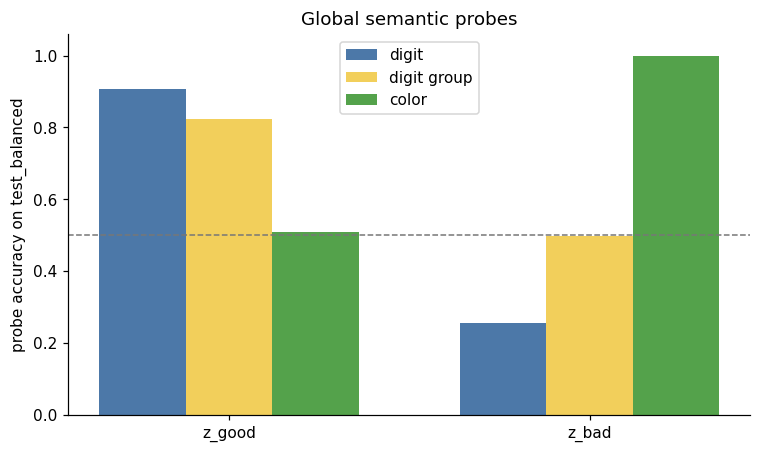

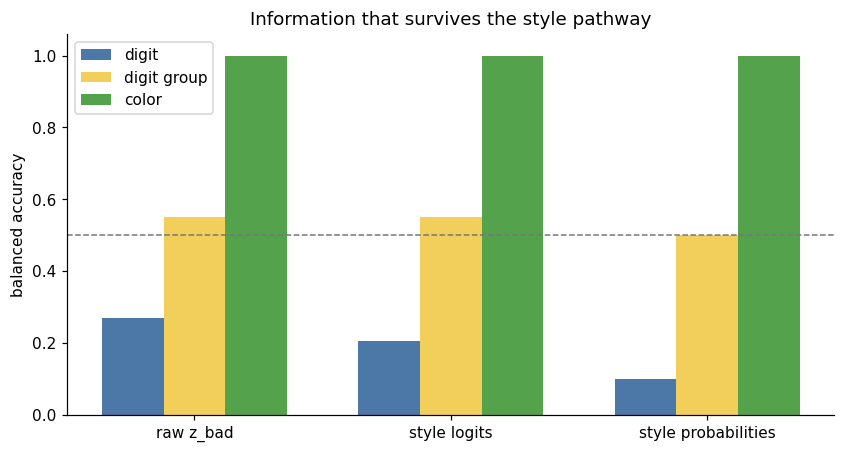

Within-digit z_good color balanced accuracy: 0.5456


In [3]:
def load_json(path):
    return json.loads(path.read_text()) if path.exists() else None

factor_probe = load_json(FACTOR_PROBE_PATH)
style_probe = load_json(STYLE_PROBE_PATH)
subgroup_probe = load_json(SUBGROUP_PATH)
counterfactual_result = load_json(COUNTERFACTUAL_PATH)

if factor_probe is None:
    print(f"Missing: {FACTOR_PROBE_PATH}")
else:
    balanced = factor_probe["results"]["test_balanced"]
    labels = ["digits", "digit_groups", "colors"]
    label_titles = ["digit", "digit group", "color"]
    values = np.array([
        [balanced["probe_accuracy"][latent][label] for label in labels]
        for latent in ["z_good", "z_bad"]
    ])

    x_pos = np.arange(2)
    width = 0.24
    fig, ax = plt.subplots(figsize=(8, 4.5))
    palette = ["#4c78a8", "#f2cf5b", "#54a24b"]
    for idx, (title, color) in enumerate(zip(label_titles, palette)):
        ax.bar(
            x_pos + (idx - 1) * width,
            values[:, idx],
            width,
            label=title,
            color=color,
        )
    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1)
    ax.set_xticks(x_pos, ["z_good", "z_bad"])
    ax.set_ylim(0, 1.06)
    ax.set_ylabel("probe accuracy on test_balanced")
    ax.set_title("Global semantic probes")
    ax.legend()
    plt.show()

if style_probe is not None:
    balanced_style = style_probe["results"]["test_balanced"]["probe_accuracy"]
    reps = ["z_bad", "style_logits", "style_probabilities"]
    style_values = np.array([
        [
            balanced_style[rep][label]["balanced_accuracy"]
            for label in ["digits", "digit_groups", "colors"]
        ]
        for rep in reps
    ])
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for idx, (title, color) in enumerate(zip(label_titles, palette)):
        ax.bar(
            np.arange(3) + (idx - 1) * width,
            style_values[:, idx],
            width,
            label=title,
            color=color,
        )
    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1)
    ax.set_xticks(
        np.arange(3),
        ["raw z_bad", "style logits", "style probabilities"],
    )
    ax.set_ylim(0, 1.06)
    ax.set_ylabel("balanced accuracy")
    ax.set_title("Information that survives the style pathway")
    ax.legend()
    plt.show()

if subgroup_probe is not None:
    within_digit = subgroup_probe["summary"]["z_good"]["test_balanced"][
        "digit"
    ]["macro_mean_balanced_accuracy"]
    print(
        "Within-digit z_good color balanced accuracy: "
        f"{within_digit:.4f}"
    )


## 3. Test A: exact counterfactual consistency

We compare three pair types:

- **same instance, different color:** exact red/green counterfactuals;
- **same digit, different instance:** color changes and handwriting changes;
- **different digit:** both semantic identity and color change.

For $z_{\mathrm{good}}$, exact counterfactual pairs should be much closer than
different instances or different digits. For $z_{\mathrm{bad}}$, red/green
separation should remain large even for the exact same instance.

The reported distance is dimension-normalized RMSE,

$$
d(a,b)=\sqrt{\frac{1}{D}\sum_j(a_j-b_j)^2}.
$$

This prevents the 128-dimensional and 4-dimensional latents from looking
different merely because of dimensionality.


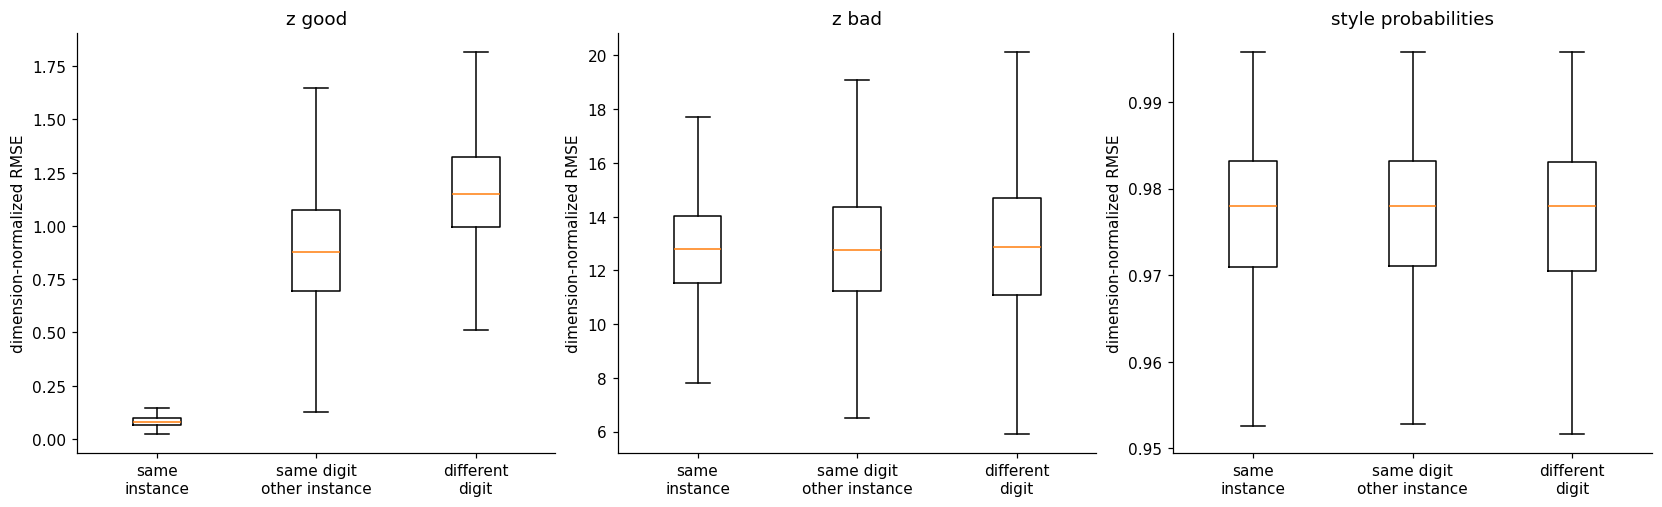

representation           same instance      same digit   different digit    same/different
--------------------------------------------------------------------------------------------
z_good                         0.08089         0.87658           1.14857           0.07043
z_bad                         12.80513        12.76021          12.87539           0.99454
style_probabilities            0.97794         0.97803           0.97798           0.99996


In [4]:
digits = image_data["digits"]
n = len(digits)

def sample_comparison_indices(labels, same_label, rng):
    result = np.empty(len(labels), dtype=np.int64)
    all_indices = np.arange(len(labels))
    for idx, label in enumerate(labels):
        if same_label:
            candidates = all_indices[(labels == label) & (all_indices != idx)]
        else:
            candidates = all_indices[labels != label]
        result[idx] = rng.choice(candidates)
    return result

same_digit_other = sample_comparison_indices(digits, True, RNG)
different_digit = sample_comparison_indices(digits, False, RNG)

def row_rmse(left, right):
    return np.sqrt(np.mean((left - right) ** 2, axis=1))

pair_distances = {}
for representation in ["z_good", "z_bad", "style_probabilities"]:
    red = encoded["red"][representation]
    green = encoded["green"][representation]
    pair_distances[representation] = {
        "same instance": row_rmse(red, green),
        "same digit, other instance": row_rmse(
            red,
            green[same_digit_other],
        ),
        "different digit": row_rmse(
            red,
            green[different_digit],
        ),
    }

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
pair_order = [
    "same instance",
    "same digit, other instance",
    "different digit",
]
for ax, representation in zip(
    axes,
    ["z_good", "z_bad", "style_probabilities"],
):
    ax.boxplot(
        [pair_distances[representation][name] for name in pair_order],
        tick_labels=["same\ninstance", "same digit\nother instance", "different\ndigit"],
        showfliers=False,
    )
    ax.set_title(representation.replace("_", " "))
    ax.set_ylabel("dimension-normalized RMSE")
plt.show()

print(
    f"{'representation':22s} {'same instance':>15s} "
    f"{'same digit':>15s} {'different digit':>17s} "
    f"{'same/different':>17s}"
)
print("-" * 92)
for representation, distances in pair_distances.items():
    medians = {
        name: float(np.median(values))
        for name, values in distances.items()
    }
    ratio = medians["same instance"] / max(
        medians["different digit"], 1e-12
    )
    print(
        f"{representation:22s} "
        f"{medians['same instance']:15.5f} "
        f"{medians['same digit, other instance']:15.5f} "
        f"{medians['different digit']:17.5f} "
        f"{ratio:17.5f}"
    )


### How to interpret Test A

- A small $z_{\mathrm{good}}$ same-instance/different-digit ratio supports
  counterfactual color invariance while preserving semantic geometry.
- A large $z_{\mathrm{bad}}$ red/green distance supports color sensitivity.
- This test does not require a trained probe and cannot be explained by the
  biased digit-color correlation, because the red and green examples share the
  exact same handwriting mask.


## 4. Test B: nearest-neighbor retrieval in $z_{\mathrm{good}}$

The retrieval pool contains both red and green counterfactuals of every test
instance. For each query we measure:

- **digit purity@k:** fraction of neighbors with the same digit;
- **opposite-color rate@k:** whether neighborhoods mix colors;
- **exact-counterfactual rank:** rank of the same handwriting in the opposite
  color.

Cosine distance is computed after feature standardization. Exact
counterfactual rank is the most direct metric: a color-invariant
representation should place the opposite-color version of the same image near
the query.


digit purity@10:       0.9334
opposite-color rate@10: 0.5364
exact-counterfactual median rank: 1.0
exact counterpart in top-10: 1.0000


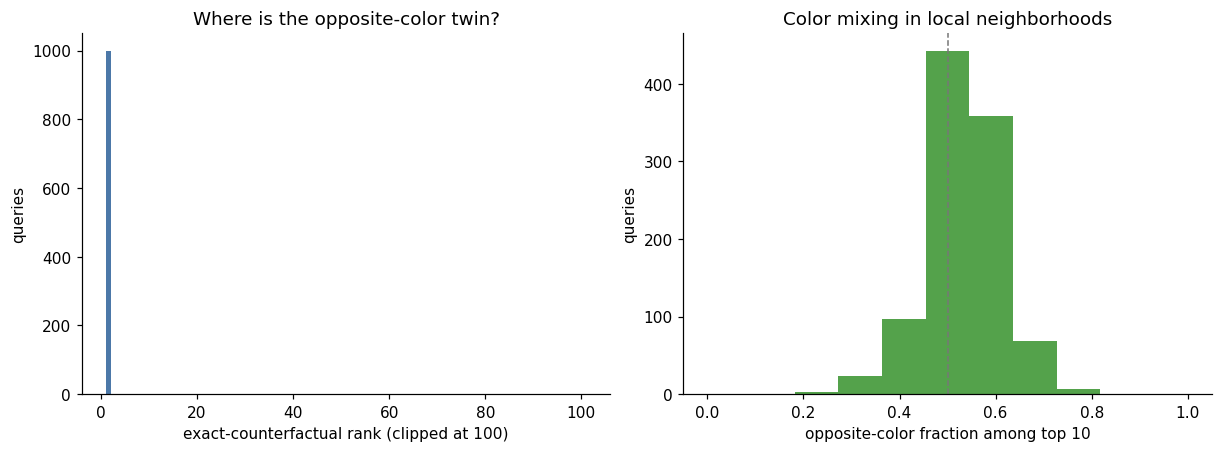

In [5]:
z_good_pool = np.concatenate([
    encoded["red"]["z_good"],
    encoded["green"]["z_good"],
], axis=0)
pool_digits = np.concatenate([digits, digits])
pool_colors = np.concatenate([
    np.zeros(n, dtype=np.int64),
    np.ones(n, dtype=np.int64),
])
pool_instances = np.concatenate([np.arange(n), np.arange(n)])

feature_mean = z_good_pool.mean(axis=0, keepdims=True)
feature_std = np.maximum(z_good_pool.std(axis=0, keepdims=True), 1e-6)
z_good_search = (z_good_pool - feature_mean) / feature_std
z_good_search /= np.maximum(
    np.linalg.norm(z_good_search, axis=1, keepdims=True),
    1e-12,
)

num_queries = min(NUM_RETRIEVAL_QUERIES, n)
query_instances = RNG.choice(n, size=num_queries, replace=False)
query_rows = query_instances  # red query for each selected instance

digit_hits = []
opposite_color_hits = []
counterfactual_ranks = []
neighbor_rows_by_query = {}

for query_row in query_rows:
    similarities = z_good_search @ z_good_search[query_row]
    similarities[query_row] = -np.inf
    top_rows = np.argpartition(
        -similarities,
        RETRIEVAL_K,
    )[:RETRIEVAL_K]
    top_rows = top_rows[np.argsort(-similarities[top_rows])]
    neighbor_rows_by_query[int(query_row)] = top_rows

    digit_hits.append(
        np.mean(pool_digits[top_rows] == pool_digits[query_row])
    )
    opposite_color_hits.append(
        np.mean(pool_colors[top_rows] != pool_colors[query_row])
    )

    counterpart_row = query_row + n
    rank = 1 + int(np.sum(
        similarities > similarities[counterpart_row]
    ))
    counterfactual_ranks.append(rank)

print(f"digit purity@{RETRIEVAL_K}:       {np.mean(digit_hits):.4f}")
print(
    f"opposite-color rate@{RETRIEVAL_K}: "
    f"{np.mean(opposite_color_hits):.4f}"
)
print(
    "exact-counterfactual median rank: "
    f"{np.median(counterfactual_ranks):.1f}"
)
print(
    f"exact counterpart in top-{RETRIEVAL_K}: "
    f"{np.mean(np.asarray(counterfactual_ranks) <= RETRIEVAL_K):.4f}"
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].hist(
    np.clip(counterfactual_ranks, 1, 100),
    bins=np.arange(1, 102),
    color="#4c78a8",
)
axes[0].set_xlabel("exact-counterfactual rank (clipped at 100)")
axes[0].set_ylabel("queries")
axes[0].set_title("Where is the opposite-color twin?")

axes[1].hist(
    opposite_color_hits,
    bins=np.linspace(0, 1, RETRIEVAL_K + 2),
    color="#54a24b",
)
axes[1].axvline(0.5, color="#777777", linestyle="--", linewidth=1)
axes[1].set_xlabel(f"opposite-color fraction among top {RETRIEVAL_K}")
axes[1].set_ylabel("queries")
axes[1].set_title("Color mixing in local neighborhoods")
plt.show()


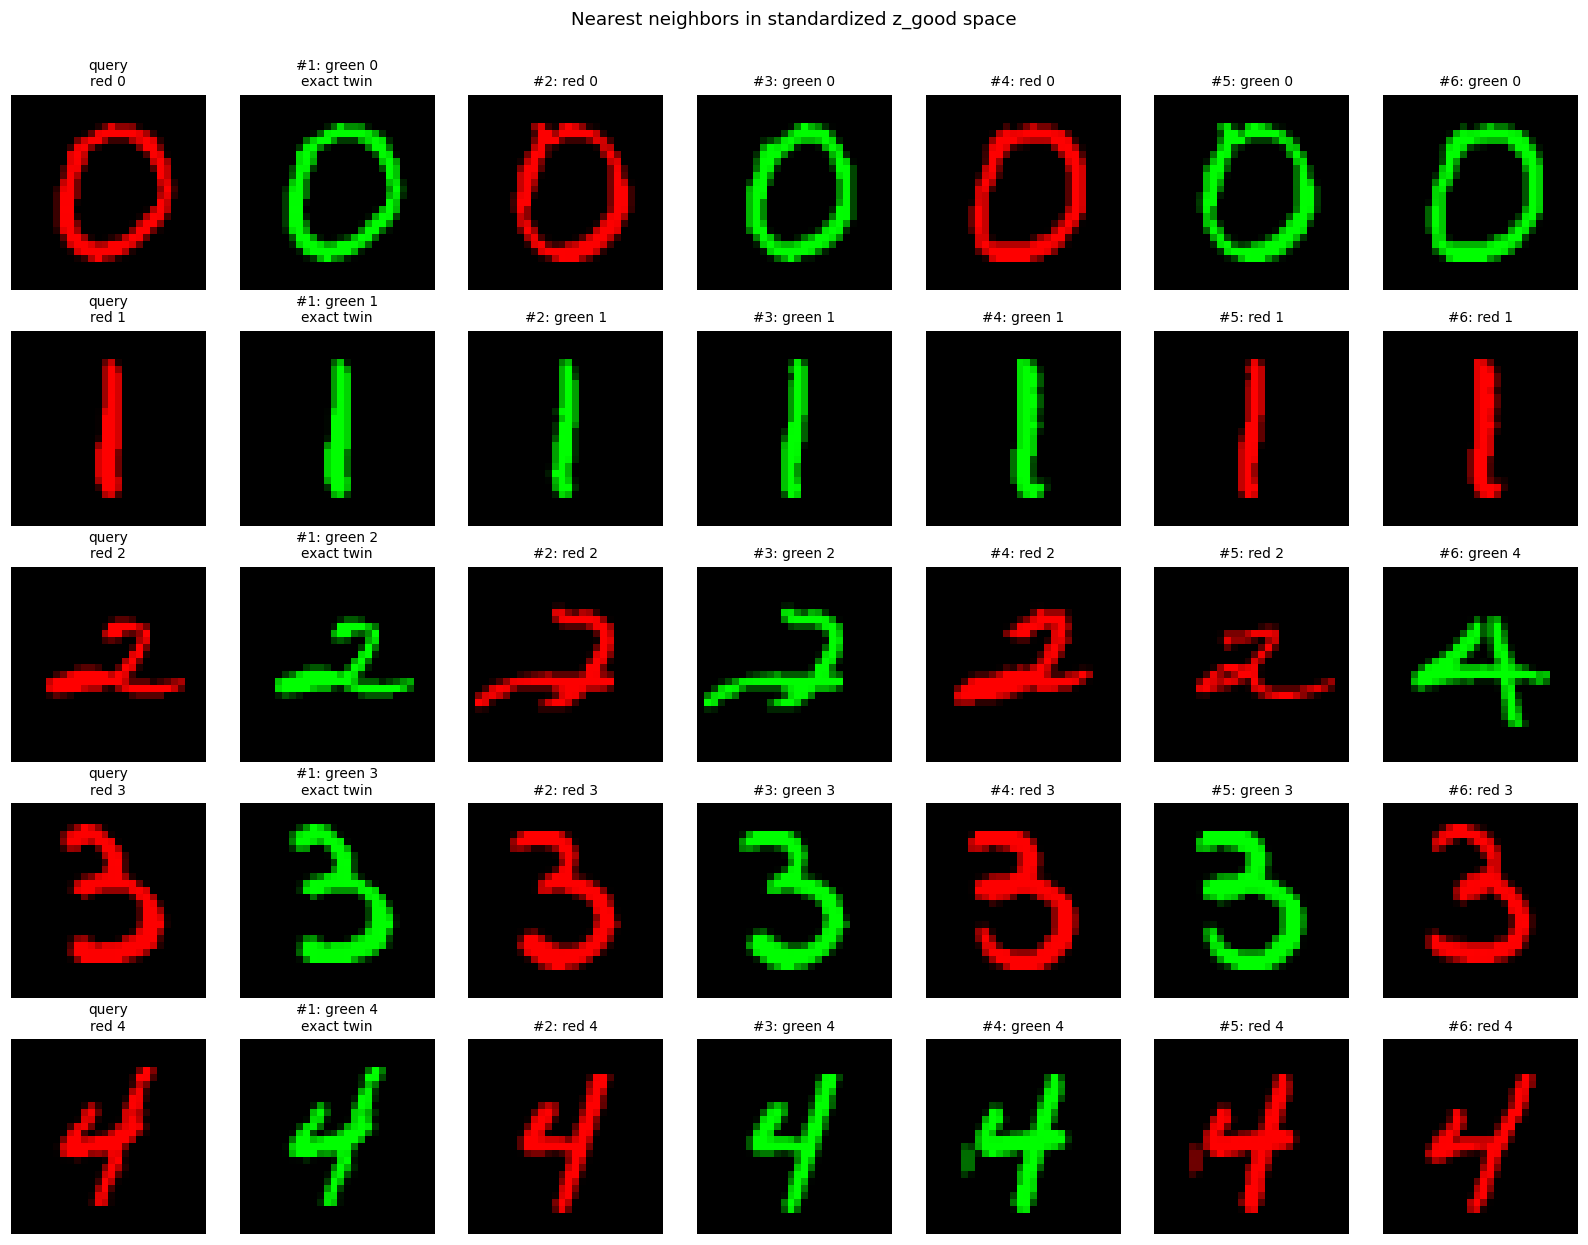

In [6]:
def paired_image(instance_index, color):
    recolored = canonical_good.recolor_images(
        image_data["images"][instance_index:instance_index + 1],
        color_index=color,
    )[0]
    return image_from_array(recolored)

visual_queries = []
for digit in range(10):
    matches = query_instances[digits[query_instances] == digit]
    if len(matches):
        visual_queries.append(int(matches[0]))
    if len(visual_queries) == NUM_VISUAL_QUERIES:
        break

num_columns = 1 + min(RETRIEVAL_K, 6)
fig, axes = plt.subplots(
    len(visual_queries),
    num_columns,
    figsize=(2.1 * num_columns, 2.25 * len(visual_queries)),
    squeeze=False,
)
for row_idx, query_instance in enumerate(visual_queries):
    query_row = query_instance
    axes[row_idx, 0].imshow(paired_image(query_instance, 0))
    axes[row_idx, 0].set_title(
        f"query\nred {digits[query_instance]}",
        fontsize=9,
    )

    neighbors = neighbor_rows_by_query[query_row][:num_columns - 1]
    for col_idx, neighbor_row in enumerate(neighbors, start=1):
        instance = int(pool_instances[neighbor_row])
        color = int(pool_colors[neighbor_row])
        exact = instance == query_instance
        axes[row_idx, col_idx].imshow(paired_image(instance, color))
        axes[row_idx, col_idx].set_title(
            f"#{col_idx}: {COLOR_NAMES[color]} {digits[instance]}"
            + ("\nexact twin" if exact else ""),
            fontsize=9,
        )
    for ax in axes[row_idx]:
        ax.axis("off")

fig.suptitle(
    "Nearest neighbors in standardized z_good space",
    y=1.002,
)
fig.tight_layout()
plt.show()


## 5. Claim 2: inspect the decoder-facing style probabilities

The style indices are permutation-symmetric during training. We infer the
red/green naming from aggregate predictions, then inspect probability
distributions by true color and digit.

The important representation is not raw $z_{\mathrm{bad}}$ but
$\pi=\mathrm{softmax}(S(z_{\mathrm{bad}}))$, because $\pi$ is what the decoder
actually consumes.


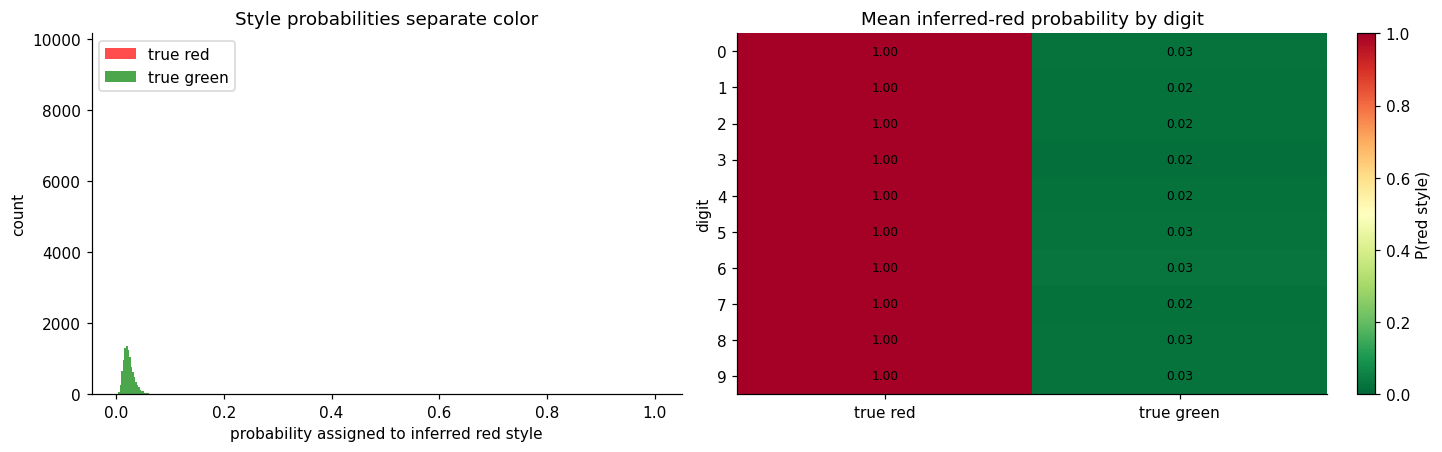

In [7]:
style_red = color_to_style[0]
p_red = np.concatenate([
    encoded["red"]["style_probabilities"][:, style_red],
    encoded["green"]["style_probabilities"][:, style_red],
])
style_colors = np.concatenate([
    np.zeros(n, dtype=np.int64),
    np.ones(n, dtype=np.int64),
])
style_digits = np.concatenate([digits, digits])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].hist(
    p_red[style_colors == 0],
    bins=30,
    alpha=0.7,
    label="true red",
    color="red",
)
axes[0].hist(
    p_red[style_colors == 1],
    bins=30,
    alpha=0.7,
    label="true green",
    color="green",
)
axes[0].set_xlabel("probability assigned to inferred red style")
axes[0].set_ylabel("count")
axes[0].set_title("Style probabilities separate color")
axes[0].legend()

digit_color_means = np.zeros((10, 2))
for digit in range(10):
    for color in [0, 1]:
        mask = (style_digits == digit) & (style_colors == color)
        digit_color_means[digit, color] = p_red[mask].mean()

heat = axes[1].imshow(
    digit_color_means,
    vmin=0,
    vmax=1,
    cmap="RdYlGn_r",
    aspect="auto",
)
axes[1].set_xticks([0, 1], ["true red", "true green"])
axes[1].set_yticks(range(10))
axes[1].set_ylabel("digit")
axes[1].set_title("Mean inferred-red probability by digit")
for digit in range(10):
    for color in [0, 1]:
        axes[1].text(
            color,
            digit,
            f"{digit_color_means[digit, color]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )
fig.colorbar(heat, ax=axes[1], label="P(red style)")
plt.show()


## 6. Tests C and E: donor-style intervention and latent swap grid

We hold the source content fixed and route it using $z_{\mathrm{bad}}$ from
another example. This uses the actual learned pathway:

$$
z_{\mathrm{bad}}^{(j)}
\rightarrow S
\rightarrow \pi^{(j)}
\rightarrow \sum_k \pi_k^{(j)}T_k(c^{(i)}).
$$

No color label is fed into reconstruction. Labels are used only afterward to
score whether the donor style changed color while source digit identity was
preserved.

The quantitative test deliberately uses **random donors of the requested
color**, not the same-instance counterfactual. If donor identity leaks through
the decoder-facing style code, reconstruction quality or digit identity should
change with the donor.


In [8]:
semantic_probes = fit_semantic_probes(
    embedding_dir / "ae_train_balanced.npz",
    mean,
    std,
    max_iter=1000,
    seed=SEED,
)

original_colors = image_data["colors"]
z_good_original = np.where(
    original_colors[:, None] == 0,
    encoded["red"]["z_good"],
    encoded["green"]["z_good"],
).astype(np.float32)

def decode_content_numpy(z_good_values):
    parts = []
    with torch.no_grad():
        for start_idx in range(0, len(z_good_values), BATCH_SIZE):
            batch = torch.from_numpy(
                z_good_values[start_idx:start_idx + BATCH_SIZE]
            ).to(device)
            parts.append(model.decode_good(batch).cpu().numpy())
    return np.concatenate(parts).astype(np.float32)

content_original = decode_content_numpy(z_good_original)

def random_donor_indices(num_examples, rng):
    donor = rng.permutation(num_examples)
    fixed = donor == np.arange(num_examples)
    if fixed.any():
        donor[fixed] = np.roll(donor, 1)[fixed]
    return donor

donor_indices = {
    color: random_donor_indices(n, RNG)
    for color in ["red", "green"]
}

def apply_donor_style(content_values, donor_z_bad):
    outputs, probabilities = [], []
    with torch.no_grad():
        for start_idx in range(0, len(content_values), BATCH_SIZE):
            content_t = torch.from_numpy(
                content_values[start_idx:start_idx + BATCH_SIZE]
            ).to(device)
            z_bad_t = torch.from_numpy(
                donor_z_bad[start_idx:start_idx + BATCH_SIZE]
            ).to(device)
            _, weights = model.decode_style(z_bad_t)
            outputs.append(model.apply_style(content_t, weights).cpu().numpy())
            probabilities.append(weights.cpu().numpy())
    return (
        np.concatenate(outputs).astype(np.float32),
        np.concatenate(probabilities).astype(np.float32),
    )

swap_outputs = {}
swap_probabilities = {}
for color in ["red", "green"]:
    donor_z_bad = encoded[color]["z_bad"][donor_indices[color]]
    swap_outputs[color], swap_probabilities[color] = apply_donor_style(
        content_original,
        donor_z_bad,
    )

def row_mse(left, right):
    return np.mean((left - right) ** 2, axis=1)

swap_summary = {}
for color_index, color in enumerate(["red", "green"]):
    output = swap_outputs[color]
    digit_predictions = semantic_probes["digit"].predict(output)
    color_predictions = semantic_probes["color"].predict(output)
    target = paired_embeddings[color]
    wrong_target = paired_embeddings["green" if color == "red" else "red"]
    swap_summary[color] = {
        "target_mse": float(row_mse(output, target).mean()),
        "wrong_target_mse": float(row_mse(output, wrong_target).mean()),
        "target_preference": float(
            (row_mse(output, target) < row_mse(output, wrong_target)).mean()
        ),
        "digit_accuracy": float(
            accuracy_score(digits, digit_predictions)
        ),
        "color_accuracy": float(
            accuracy_score(
                np.full(n, color_index, dtype=np.int64),
                color_predictions,
            )
        ),
    }

display(Markdown(
    "| donor style | target MSE | wrong-color MSE | target preference "
    "| source digit accuracy | requested color accuracy |\n"
    "|---|---:|---:|---:|---:|---:|\n"
    + "\n".join(
        f"| {color} | {metrics['target_mse']:.4f} "
        f"| {metrics['wrong_target_mse']:.4f} "
        f"| {metrics['target_preference']:.4f} "
        f"| {metrics['digit_accuracy']:.4f} "
        f"| {metrics['color_accuracy']:.4f} |"
        for color, metrics in swap_summary.items()
    )
))

# A second donor with the same color tests whether donor identity matters.
donor_indices_2 = {
    color: random_donor_indices(n, RNG)
    for color in ["red", "green"]
}
donor_sensitivity = {}
for color in ["red", "green"]:
    second_output, _ = apply_donor_style(
        content_original,
        encoded[color]["z_bad"][donor_indices_2[color]],
    )
    donor_sensitivity[color] = float(
        row_mse(swap_outputs[color], second_output).mean()
    )

print("Output MSE after changing donor identity but keeping donor color:")
for color, value in donor_sensitivity.items():
    print(f"  {color:5s}: {value:.8f}")


| donor style | target MSE | wrong-color MSE | target preference | source digit accuracy | requested color accuracy |
|---|---:|---:|---:|---:|---:|
| red | 0.1604 | 2.1887 | 1.0000 | 0.8781 | 1.0000 |
| green | 0.1256 | 2.6709 | 1.0000 | 0.8737 | 1.0000 |

Output MSE after changing donor identity but keeping donor color:
  red  : 0.00000000
  green: 0.00043633


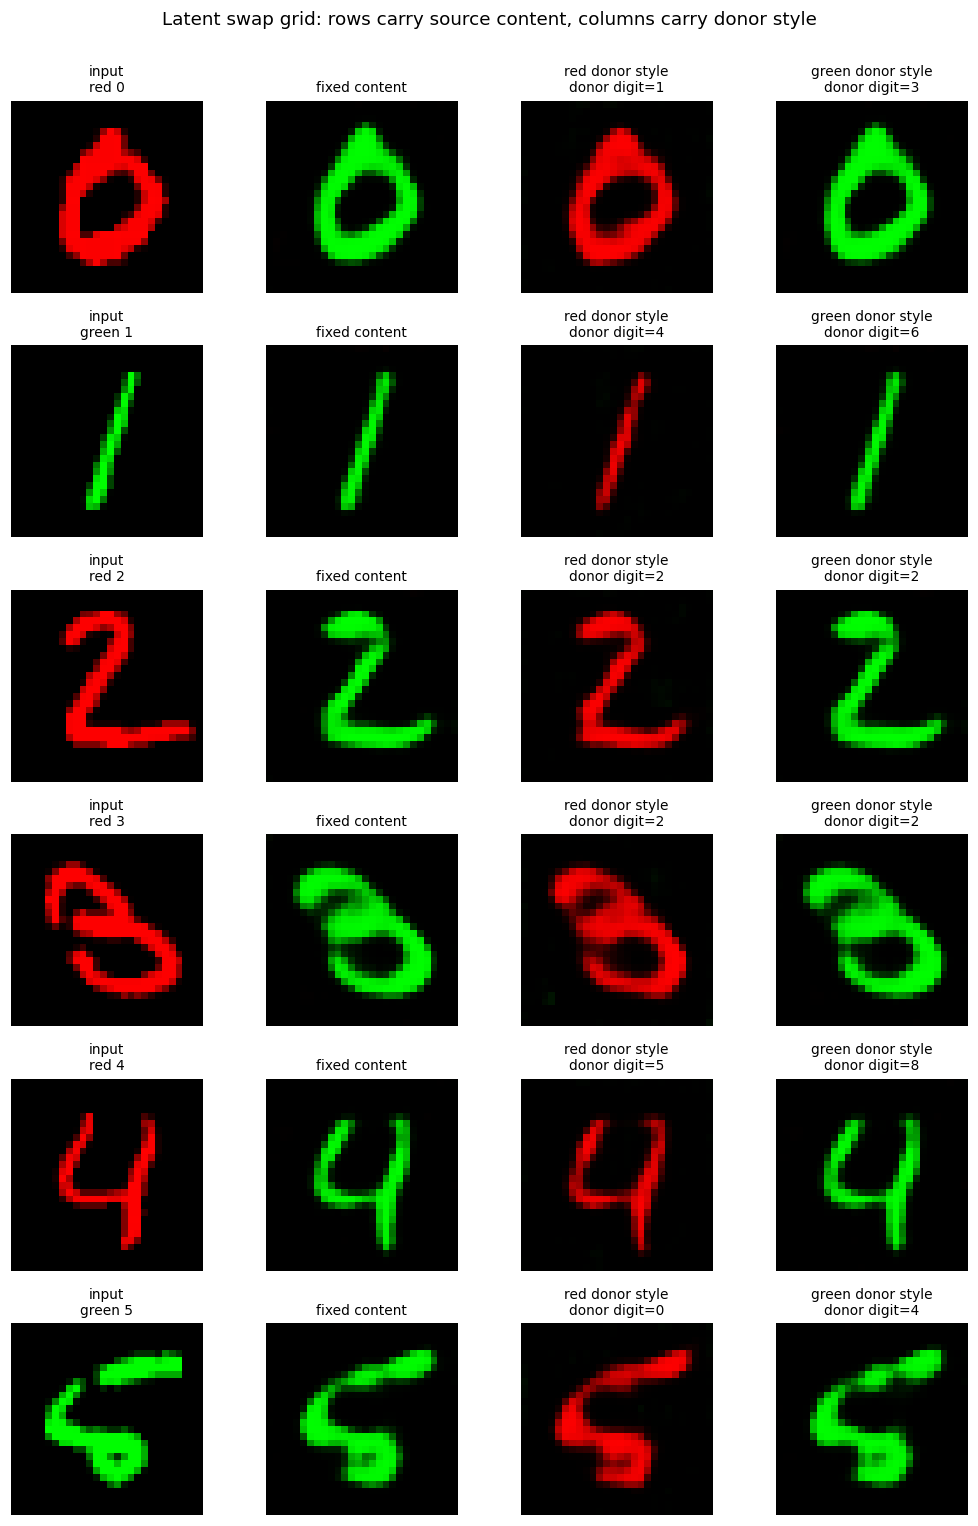

In [9]:
mean_t = torch.from_numpy(mean).to(device)
std_t = torch.from_numpy(std).to(device)

def decode_standardized_numpy(values):
    images = []
    with torch.no_grad():
        for start_idx in range(0, len(values), BATCH_SIZE):
            batch = torch.from_numpy(
                values[start_idx:start_idx + BATCH_SIZE]
            ).to(device)
            images.append(
                base_ae.decode(batch * std_t + mean_t).cpu()
            )
    return torch.cat(images, dim=0)

visual_rows = []
for digit in range(10):
    matches = np.flatnonzero(digits == digit)
    if len(matches):
        visual_rows.append(int(matches[0]))
    if len(visual_rows) == NUM_SWAP_ROWS:
        break

content_images = decode_standardized_numpy(content_original[visual_rows])
red_swap_images = decode_standardized_numpy(
    swap_outputs["red"][visual_rows]
)
green_swap_images = decode_standardized_numpy(
    swap_outputs["green"][visual_rows]
)

fig, axes = plt.subplots(
    len(visual_rows),
    4,
    figsize=(9.5, 2.3 * len(visual_rows)),
    squeeze=False,
)
for row_idx, source_idx in enumerate(visual_rows):
    source_color = int(original_colors[source_idx])
    axes[row_idx, 0].imshow(
        image_from_array(image_data["images"][source_idx])
    )
    axes[row_idx, 0].set_title(
        f"input\n{COLOR_NAMES[source_color]} {digits[source_idx]}",
        fontsize=9,
    )
    axes[row_idx, 1].imshow(image_from_tensor(content_images[row_idx]))
    axes[row_idx, 1].set_title("fixed content", fontsize=9)

    red_donor = int(donor_indices["red"][source_idx])
    axes[row_idx, 2].imshow(image_from_tensor(red_swap_images[row_idx]))
    axes[row_idx, 2].set_title(
        f"red donor style\ndonor digit={digits[red_donor]}",
        fontsize=9,
    )

    green_donor = int(donor_indices["green"][source_idx])
    axes[row_idx, 3].imshow(
        image_from_tensor(green_swap_images[row_idx])
    )
    axes[row_idx, 3].set_title(
        f"green donor style\ndonor digit={digits[green_donor]}",
        fontsize=9,
    )
    for ax in axes[row_idx]:
        ax.axis("off")

fig.suptitle(
    "Latent swap grid: rows carry source content, columns carry donor style",
    y=1.002,
)
fig.tight_layout()
plt.show()


### How to interpret the intervention

Support for the nuisance-only claim requires all three:

1. requested color accuracy remains high;
2. source digit accuracy remains high;
3. replacing a donor with another donor of the same color barely changes the
   output.

The factorized architecture makes this test especially meaningful because the
bad branch cannot emit an independent 64-dimensional digit reconstruction. It
can only select a mixture of globally shared content transforms.


## 7. Test D: closest existing additive-decoder comparison

This section compares the factorized run with the closest saved additive run:
green canonical target, $z_{\mathrm{bad}}=4$, paired invariance, scheduled
training, and the same seed.

This is useful evidence, but it is **not a perfectly controlled decoder-only
ablation** because some objective schedule details differ. A thesis-level
causal claim that the decoder alone caused the improvement should eventually
use a rerun where every non-architectural hyperparameter is matched.


| metric | additive | factorized | factorized - additive |
|---|---:|---:|---:|
| reconstruction MSE | 0.4008 | 0.1400 | -0.2608 |
| z_good digit | 0.9030 | 0.9069 | +0.0039 |
| z_good color | 0.5116 | 0.5091 | -0.0025 |
| within-digit z_good color | 0.5919 | 0.5456 | -0.0464 |
| z_bad digit | 0.3421 | 0.2564 | -0.0857 |
| z_bad color | 0.9995 | 1.0000 | +0.0005 |

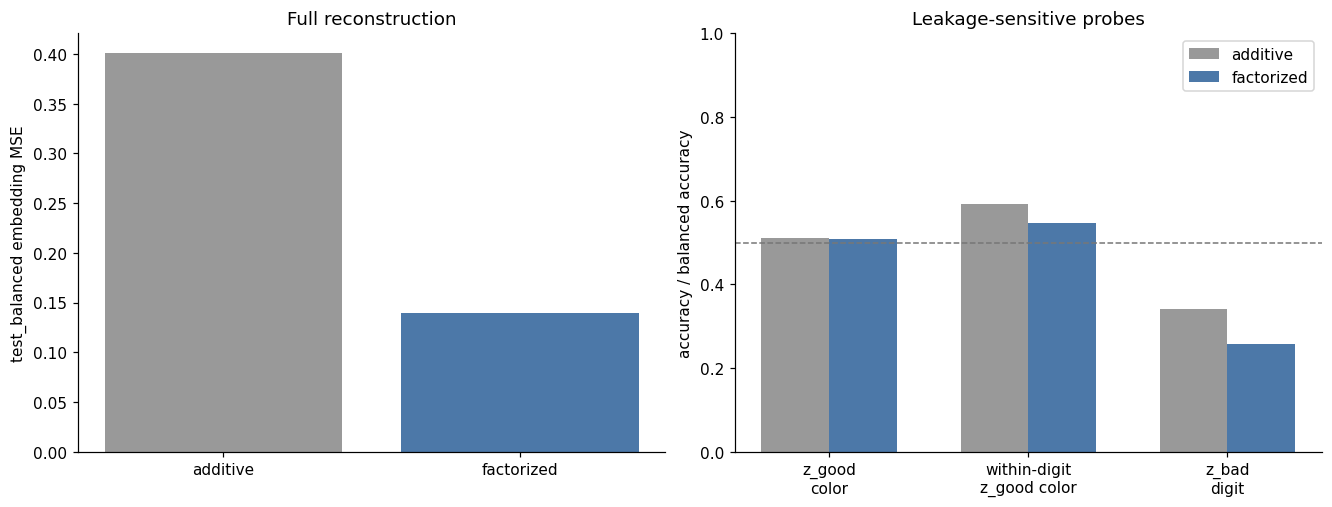

In [10]:
additive_probe = load_json(ADDITIVE_PROBE_PATH)
additive_subgroup = load_json(ADDITIVE_SUBGROUP_PATH)

if factor_probe is None or additive_probe is None:
    print("One or both global probe result files are missing.")
else:
    comparisons = {}
    for name, result, subgroup in [
        ("additive", additive_probe, additive_subgroup),
        ("factorized", factor_probe, subgroup_probe),
    ]:
        balanced = result["results"]["test_balanced"]
        comparisons[name] = {
            "reconstruction MSE": balanced["diagnostics"]["recon_mse"],
            "z_good digit": balanced["probe_accuracy"]["z_good"]["digits"],
            "z_good color": balanced["probe_accuracy"]["z_good"]["colors"],
            "z_bad digit": balanced["probe_accuracy"]["z_bad"]["digits"],
            "z_bad color": balanced["probe_accuracy"]["z_bad"]["colors"],
        }
        if subgroup is not None:
            comparisons[name]["within-digit z_good color"] = subgroup[
                "summary"
            ]["z_good"]["test_balanced"]["digit"][
                "macro_mean_balanced_accuracy"
            ]

    metric_order = [
        "reconstruction MSE",
        "z_good digit",
        "z_good color",
        "within-digit z_good color",
        "z_bad digit",
        "z_bad color",
    ]
    display(Markdown(
        "| metric | additive | factorized | factorized - additive |\n"
        "|---|---:|---:|---:|\n"
        + "\n".join(
            f"| {metric} "
            f"| {comparisons['additive'].get(metric, float('nan')):.4f} "
            f"| {comparisons['factorized'].get(metric, float('nan')):.4f} "
            f"| {comparisons['factorized'].get(metric, float('nan')) - comparisons['additive'].get(metric, float('nan')):+.4f} |"
            for metric in metric_order
        )
    ))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    axes[0].bar(
        ["additive", "factorized"],
        [
            comparisons["additive"]["reconstruction MSE"],
            comparisons["factorized"]["reconstruction MSE"],
        ],
        color=["#999999", "#4c78a8"],
    )
    axes[0].set_ylabel("test_balanced embedding MSE")
    axes[0].set_title("Full reconstruction")

    leakage_metrics = [
        "z_good color",
        "within-digit z_good color",
        "z_bad digit",
    ]
    x_pos = np.arange(len(leakage_metrics))
    width = 0.34
    for offset, name, color in [
        (-width / 2, "additive", "#999999"),
        (width / 2, "factorized", "#4c78a8"),
    ]:
        axes[1].bar(
            x_pos + offset,
            [comparisons[name][metric] for metric in leakage_metrics],
            width,
            label=name,
            color=color,
        )
    axes[1].axhline(0.5, color="#777777", linestyle="--", linewidth=1)
    axes[1].set_xticks(
        x_pos,
        ["z_good\ncolor", "within-digit\nz_good color", "z_bad\ndigit"],
    )
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("accuracy / balanced accuracy")
    axes[1].set_title("Leakage-sensitive probes")
    axes[1].legend()
    plt.show()


## 8. Claim scorecard

The table below is generated from this notebook's results. The language is
deliberately conservative:

- **supported** means the selected tests behave in the expected direction;
- **qualified** means the main behavior is present but measurable leakage or
  an ablation limitation remains;
- none of these tests prove statistical independence in the information-
  theoretic sense.


In [11]:
z_good_same = np.median(
    pair_distances["z_good"]["same instance"]
)
z_good_diff = np.median(
    pair_distances["z_good"]["different digit"]
)
pair_ratio = z_good_same / max(z_good_diff, 1e-12)
counterpart_topk = np.mean(
    np.asarray(counterfactual_ranks) <= RETRIEVAL_K
)

style_prob_digit = None
style_prob_color = None
if style_probe is not None:
    style_metrics = style_probe["results"]["test_balanced"][
        "probe_accuracy"
    ]["style_probabilities"]
    style_prob_digit = style_metrics["digits"]["balanced_accuracy"]
    style_prob_color = style_metrics["colors"]["balanced_accuracy"]

scorecard = [
    (
        "z_good is counterfactually color-stable",
        f"paired/different-digit distance ratio={pair_ratio:.3f}; "
        f"exact twin top-{RETRIEVAL_K}={counterpart_topk:.3f}",
        "supported" if pair_ratio < 0.5 else "qualified",
        "Within-digit and nonlinear leakage must still be reported.",
    ),
    (
        "style probabilities represent color",
        (
            f"digit bal.={style_prob_digit:.3f}; "
            f"color bal.={style_prob_color:.3f}"
            if style_prob_digit is not None
            else "saved balanced style probe unavailable"
        ),
        (
            "supported"
            if style_prob_digit is not None
            and style_prob_digit <= 0.2
            and style_prob_color >= 0.95
            else "qualified"
        ),
        "This concerns decoder-facing probabilities, not all of raw z_bad.",
    ),
    (
        "z_bad intervention changes style, not identity",
        (
            f"red digit/color={swap_summary['red']['digit_accuracy']:.3f}/"
            f"{swap_summary['red']['color_accuracy']:.3f}; "
            f"green={swap_summary['green']['digit_accuracy']:.3f}/"
            f"{swap_summary['green']['color_accuracy']:.3f}"
        ),
        (
            "supported"
            if min(
                swap_summary["red"]["digit_accuracy"],
                swap_summary["green"]["digit_accuracy"],
            ) >= 0.8
            and min(
                swap_summary["red"]["color_accuracy"],
                swap_summary["green"]["color_accuracy"],
            ) >= 0.95
            else "qualified"
        ),
        "Digit preservation is measured with a frozen embedding probe.",
    ),
]

if factor_probe is not None and additive_probe is not None:
    recon_factor = factor_probe["results"]["test_balanced"][
        "diagnostics"
    ]["recon_mse"]
    recon_add = additive_probe["results"]["test_balanced"][
        "diagnostics"
    ]["recon_mse"]
    scorecard.append((
        "factorization improves the saved additive baseline",
        f"balanced reconstruction MSE {recon_add:.3f} -> {recon_factor:.3f}",
        "supported",
        "Closest existing comparison; a matched decoder-only rerun is stronger.",
    ))

display(Markdown(
    "| claim | evidence | status | remaining caveat |\n"
    "|---|---|---|---|\n"
    + "\n".join(
        f"| {claim} | {evidence} | **{status}** | {caveat} |"
        for claim, evidence, status, caveat in scorecard
    )
))


| claim | evidence | status | remaining caveat |
|---|---|---|---|
| z_good is counterfactually color-stable | paired/different-digit distance ratio=0.070; exact twin top-10=1.000 | **supported** | Within-digit and nonlinear leakage must still be reported. |
| style probabilities represent color | digit bal.=0.100; color bal.=1.000 | **supported** | This concerns decoder-facing probabilities, not all of raw z_bad. |
| z_bad intervention changes style, not identity | red digit/color=0.878/1.000; green=0.874/1.000 | **supported** | Digit preservation is measured with a frozen embedding probe. |
| factorization improves the saved additive baseline | balanced reconstruction MSE 0.401 -> 0.140 | **supported** | Closest existing comparison; a matched decoder-only rerun is stronger. |

## 9. Recommended reporting language

A defensible conclusion is:

> On exact red/green counterfactual pairs, the factorized model preserves
> digit content in $z_{\mathrm{good}}$ while routing color through a compact
> decoder-facing style distribution. Forced and donor-based style
> interventions change reconstructed color while largely preserving source
> identity. Linear and within-digit probes show that residual color leakage in
> $z_{\mathrm{good}}$ is small but not necessarily zero.

Avoid the stronger statements “$z_{\mathrm{good}}$ contains no color
information” and “$z_{\mathrm{bad}}$ is statistically independent of digit.”
The current experiments support functional separation and strong suppression,
not a proof of complete independence.

### Strongest remaining experiment

Run a matched additive-versus-factorized ablation with identical data order,
seed, schedule, losses, latent dimensions, and checkpoint selection. The
current saved comparison is informative, but this matched run is needed to
attribute the gain specifically to decoder factorization.
